In [1]:
import sys
import os
sys.path.append(os.path.abspath('..'))
from src.linear_regression import train
from src.preprocessing import preprocess

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### This notebook will use basic linear regression, followed by lasso linear regression, to use as a baseline for comparison with more advanced models

In [2]:
# -- Raw training data
clean_train = preprocess(pd.read_csv("../data/raw/train_raw.csv") )

# --Defining targets and model/scores dictionaries
targets = []
for col in clean_train.columns:
    if col.startswith('log_'):
        targets.append(col)
    elif clean_train[col].dtype in ['float64', 'int64']:
        # Only add raw column if no log version exists
        log_version = f'log_{col}'
        if log_version not in clean_train.columns:
            targets.append(col)
            
lin_reg_models = {}
lin_reg_scores = {}
lin_reg_data = {}

#### Linear Regression

In [3]:
# -- Linear Regression
for target in targets:
    model, scores, X, y, y_pred_cv = train(clean_train, target)
    lin_reg_models[target] = model
    lin_reg_scores[target] = scores
    lin_reg_data[target] = (X, y, y_pred_cv)

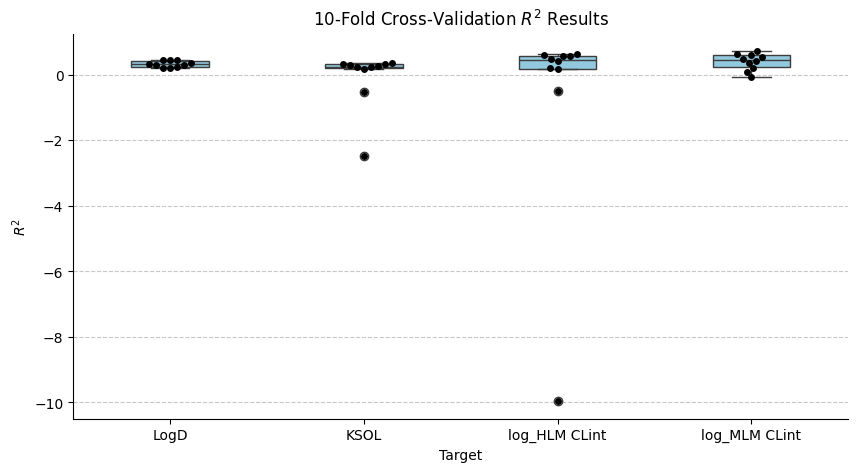

In [4]:
scores_df = pd.DataFrame(lin_reg_scores)

plt.figure(figsize=(10, 5))
sns.boxplot(data=scores_df, color='skyblue', width=0.4)
sns.swarmplot(data=scores_df, color='black')

plt.title(r'10-Fold Cross-Validation $R^2$ Results')
plt.ylabel(r'$R^2$')
plt.xlabel('Target')
plt.grid(axis='y', linestyle='--', alpha=0.7)
sns.despine()
plt.show()

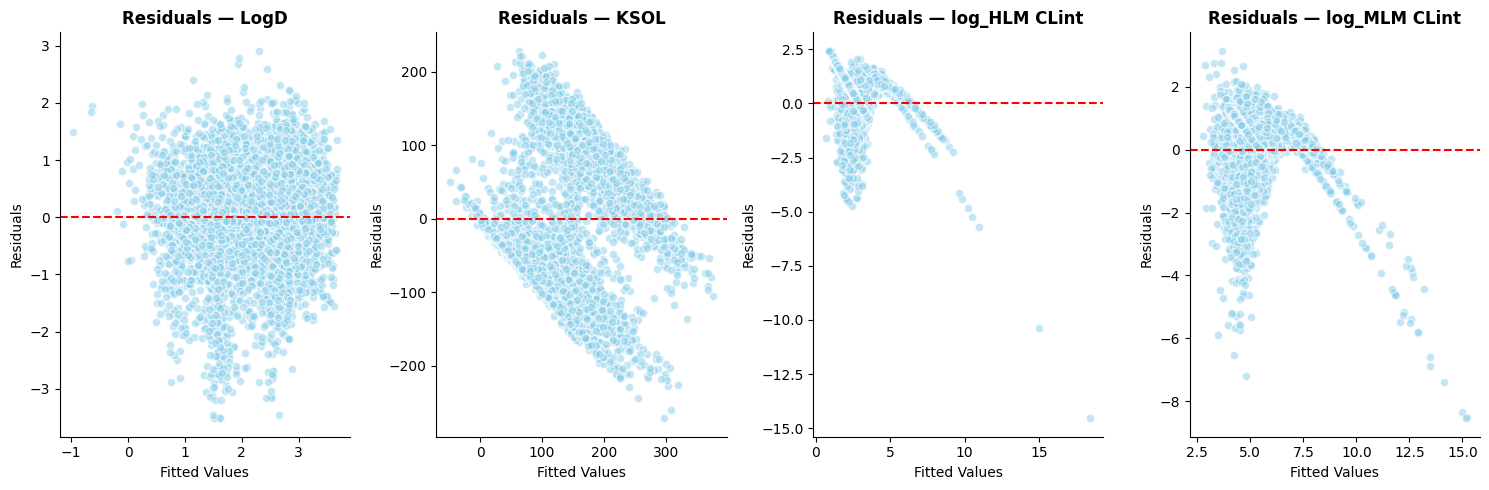

In [5]:
fig, axes = plt.subplots(1, 4, figsize=(15, 5))
for ax, (target, model) in zip(axes, lin_reg_models.items()):
    X, y, y_pred_cv = lin_reg_data[target]
    y_pred = model.predict(X)
    residuals = y - y_pred_cv
    ax.scatter(y_pred, residuals, alpha=0.5, color='skyblue', edgecolors='white')
    ax.axhline(y=0, color='red', linestyle='--')
    ax.set_title(f'Residuals — {target}', fontweight='bold')
    ax.set_xlabel('Fitted Values')
    ax.set_ylabel('Residuals')
    sns.despine(ax=ax)

plt.tight_layout()
plt.show()

Basic linear regression residuals show heteroskedasticity, suggesting the models fail to capture non-linear relationships in the data

In [3]:
clean_test = preprocess(pd.read_csv("../data/raw/test_raw.csv"))

In [4]:
clean_test

,Molecule Name,SMILES,LogD,KSOL,HLM CLint,MLM CLint,LogD_censored,KSOL_censored,HLM CLint_censored,RLM CLint_censored,MLM CLint_censored,Caco-2 Permeability Papp A>B_censored,Caco-2 Permeability Efflux_censored,MPPB_censored,MBPB_censored,MGMB_censored,log_HLM CLint,log_MLM CLint
0,E-0001321,CN1CCC[C@H]1COc1ccc(-c2nc3cc(-c4ccc5[nH]c(-c6c...,2.12087,154.304043,56.4,182.3,False,False,0,False,0,False,False,False,False,False,4.032469,5.205654
1,E-0001780,COc1ccc2c(c1)c1cc3cnccc3c(C)c1n2C,2.12087,154.304043,160.4,1351.1,False,False,0,False,0,False,False,False,False,False,5.077671,7.208674
2,E-0001827,Cc1c2ccncc2cc2c3cc(OCCCN4CCN(C)CC4)ccc3n(C)c12,2.12087,154.304043,17.0,193.5,False,False,False,False,0,False,False,False,False,False,2.869213,5.265278
3,E-0001829,Cc1c2ccnc(C(=O)N[C@H](C)CN(C)C)c2cc2c3cc(OCCCN...,2.12087,154.304043,4.7,393.0,False,False,0,False,0,False,False,False,False,False,1.547563,5.973810
4,E-0002019,CN(C)CCCOc1ccc(-c2nc3cc(NC(=O)c4ccc5[nH]c(-c6c...,2.12087,154.304043,9.5,38.0,False,False,0,False,0,False,False,False,False,False,2.251292,3.637586
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7613,E-0027215,CN(C)CCNc1nc(Nc2cncn2C)cc2c(-c3cncc(N4CCN(C)CC...,1.00000,154.304043,17.0,209.6,0,False,False,False,False,0,0,False,False,False,2.869213,5.209376
7614,E-0027218,CN(C)CCNc1nc(Nc2ccncc2)cc2c(-c3cnn(C4CCN(C)CC4...,1.10000,154.304043,5.3,209.6,0,False,0,False,False,0,0,False,False,False,1.667707,5.209376
7615,E-0027231,CN(C)CCNc1nc(NC(=O)OCCN2CCCC2)cc2c(-c3cncc(N4C...,0.60000,154.304043,4.5,209.6,0,False,0,False,False,0,0,False,False,False,1.504077,5.209376
7616,E-0027235,CN(C)CCNc1nc(N2CCN(CCN(C)C)C2=O)cc2c(-c3cncc(N...,0.00000,154.304043,4.5,209.6,0,False,0,False,False,0,0,False,False,False,1.504077,5.209376
